# Fine-Tuning, PEFT, LoRA & QLoRA — Concepts and Math, From Scratch

This notebook is the companion to the animated slide deck. Where the deck builds *intuition*,
this notebook builds the **math** — and then implements every piece in plain NumPy so you can
watch the numbers move.

No GPU, no `torch`, no downloaded model required. Every idea here is small enough to fit in an
array you can print.

**Contents**

1. A layer is just a matrix
2. Training = gradient descent (the math)
3. Full fine-tuning and its memory bill
4. Counting a transformer's parameters
5. The Adam optimizer, spelled out
6. The key insight: low-rank structure (SVD + Eckart–Young)
7. LoRA: the math, derived and implemented
8. Initialization: why `B = 0`, `A = random`
9. The scaling factor `α / r`
10. Choosing rank `r`: how much "energy" you actually need
11. Merging LoRA weights back into `W`
12. QLoRA: the math of NF4 quantization
13. Double quantization: compressing the compression
14. Full memory comparison: Full FT vs LoRA vs QLoRA
15. Real-world usage with 🤗 `peft` (reference only)
16. Cheat sheet

## 1. A layer is just a matrix

Every linear layer in a neural network computes

$$
h = xW, \qquad x \in \mathbb{R}^{k}, \quad W \in \mathbb{R}^{k \times d}, \quad h \in \mathbb{R}^{d}
$$

(bias omitted — it doesn't change anything below). A large language model is a stack of dozens
of these, chained together with attention and nonlinearities. **Every entry of every `W` is one
learned number.** Training is the process of finding good values for all of them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

rng = np.random.default_rng(7)

# a toy weight matrix: 6 inputs -> 4 outputs
k, d = 6, 4
W = rng.normal(scale=0.5, size=(k, d))

print("W shape:", W.shape)
print("trainable numbers in this one layer:", W.size)
print(W.round(2))

W shape: (6, 4)
trainable numbers in this one layer: 24
[[ 0.    0.15 -0.14 -0.45]
 [-0.23 -0.5   0.03  0.67]
 [-0.25 -0.31  0.24  0.18]
 [ 0.05 -0.47 -0.01  0.35]
 [-0.67 -0.23 -0.95 -0.64]
 [-0.92 -0.12 -0.63  0.14]]


## 2. Training = gradient descent (the math)

Given a loss $L(\theta)$ scoring how wrong the model currently is, we improve $\theta$ by moving
it against the gradient — the direction of steepest increase:

$$
g_i = \frac{\partial L}{\partial \theta_i}, \qquad
\theta_i \;\leftarrow\; \theta_i - \eta \, g_i
$$

$\eta$ is the learning rate. Too large and you overshoot the minimum; too small and training crawls.

**Concrete case — linear regression.** With data $X \in \mathbb{R}^{n\times k}$, targets
$y\in\mathbb{R}^n$, and loss $L(\theta)=\frac{1}{2n}\lVert X\theta-y\rVert_2^2$, the gradient has
closed form:

$$
\nabla_\theta L = \frac{1}{n}X^\top (X\theta - y)
$$

Let's run it and watch the loss fall.

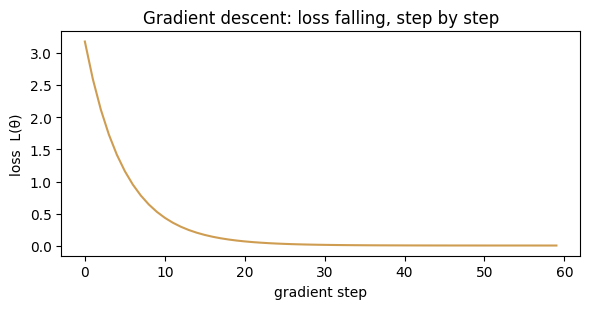

true theta:    [ 0.157 -0.187 -2.517 -0.539 -0.049  0.113]
learned theta: [ 0.148 -0.187 -2.508 -0.522 -0.056  0.094]
final loss:    0.00594


In [2]:
# synthetic linear-regression toy problem
n, k = 200, 6
true_theta = rng.normal(size=k)
X = rng.normal(size=(n, k))
y = X @ true_theta + rng.normal(scale=0.1, size=n)

theta = np.zeros(k)          # start from nothing
eta = 0.1
losses = []

for step in range(60):
    residual = X @ theta - y
    loss = 0.5 * np.mean(residual ** 2)
    grad = (X.T @ residual) / n
    theta = theta - eta * grad
    losses.append(loss)

plt.figure(figsize=(6, 3.2))
plt.plot(losses, color="#cf9d52")
plt.xlabel("gradient step")
plt.ylabel("loss  L(θ)")
plt.title("Gradient descent: loss falling, step by step")
plt.tight_layout()
plt.show()

print("true theta:   ", true_theta.round(3))
print("learned theta:", theta.round(3))
print("final loss:    %.5f" % losses[-1])

## 3. Full fine-tuning and its memory bill

Fine-tuning is exactly the recipe above, run again on new data, starting from a pretrained
$\theta_0$ instead of zeros. **Full** fine-tuning updates *every* parameter — which means every
parameter now needs, at minimum:

| quantity | who needs it | typical dtype |
|---|---|---|
| the weight itself | always | fp16 / bf16 |
| the gradient | only trainable weights | fp16 / bf16 |
| optimizer state `m` | only trainable weights (Adam) | fp32 |
| optimizer state `v` | only trainable weights (Adam) | fp32 |

Let's turn that into a formula and compute it for a realistic model size.

In [3]:
def memory_bill_gb(num_params, trainable_fraction=1.0,
                    weight_bytes=2, grad_bytes=2, opt_bytes=4, opt_states=2):
    """
    Rough memory bill in GB.
    weight_bytes: bytes per stored weight (fp16/bf16 = 2)
    grad_bytes:   bytes per gradient (only for trainable params)
    opt_bytes:    bytes per optimizer state (fp32 = 4)
    opt_states:   optimizer states per trainable param (Adam = 2: m and v)
    """
    trainable = num_params * trainable_fraction
    weights_gb   = num_params * weight_bytes / 1e9
    grads_gb     = trainable  * grad_bytes   / 1e9
    optimizer_gb = trainable  * opt_bytes * opt_states / 1e9
    total = weights_gb + grads_gb + optimizer_gb
    return {"weights_GB": weights_gb, "grads_GB": grads_gb,
            "optimizer_GB": optimizer_gb, "total_GB": total}

seven_b = 6_900_000_000   # ~7B-parameter model

full_ft = memory_bill_gb(seven_b, trainable_fraction=1.0)
print("Full fine-tuning memory bill for a ~7B model:")
for k_, v_ in full_ft.items():
    print(f"  {k_:14s}: {v_:8.1f} GB")

Full fine-tuning memory bill for a ~7B model:
  weights_GB    :     13.8 GB
  grads_GB      :     13.8 GB
  optimizer_GB  :     55.2 GB
  total_GB      :     82.8 GB


## 4. Counting a transformer's parameters

Where does "7 billion" actually come from? Inside every transformer block, with hidden size $d$:

- **Attention** — four projections, each roughly $d \times d$: $W_Q, W_K, W_V, W_O$ → $4d^2$
- **MLP** — up-projection $d \to 4d$ and down-projection $4d \to d$ → $4d^2 + 4d^2 = 8d^2$

$$
\text{params per block} \approx 4d^2 + 8d^2 = 12d^2
$$

Stack $L$ blocks:

$$
\text{total params} \approx 12\,d^2\,L
$$

(plus embeddings and a few smaller pieces, which is why real counts land a little above this).

In [4]:
def transformer_param_estimate(d_model, n_layers):
    return 12 * d_model**2 * n_layers

configs = pd.DataFrame([
    {"model": "toy (d=256, L=4)", "d_model": 256,  "layers": 4},
    {"model": "GPT-2 small-ish",  "d_model": 768,  "layers": 12},
    {"model": "~7B-class",        "d_model": 4096, "layers": 32},
    {"model": "~13B-class",       "d_model": 5120, "layers": 40},
])
configs["estimated_params"] = configs.apply(
    lambda r: transformer_param_estimate(r.d_model, r.layers), axis=1)
configs["estimated_params_B"] = (configs["estimated_params"] / 1e9).round(2)
configs

,model,d_model,layers,estimated_params,estimated_params_B
0,"toy (d=256, L=4)",256,4,3145728,0.00
1,GPT-2 small-ish,768,12,84934656,0.08
2,~7B-class,4096,32,6442450944,6.44
3,~13B-class,5120,40,12582912000,12.58


## 5. The Adam optimizer, spelled out

Plain gradient descent uses only today's gradient. Adam keeps a running memory of it:

$$
\begin{aligned}
m_t &\leftarrow \beta_1 m_{t-1} + (1-\beta_1)\,g_t &&\text{(momentum — smoothed direction)}\\
v_t &\leftarrow \beta_2 v_{t-1} + (1-\beta_2)\,g_t^2 &&\text{(variance — smoothed step-size scale)}\\
\hat m_t &= \frac{m_t}{1-\beta_1^t}, \quad \hat v_t = \frac{v_t}{1-\beta_2^t} &&\text{(bias correction)}\\
\theta_t &\leftarrow \theta_{t-1} - \eta \cdot \frac{\hat m_t}{\sqrt{\hat v_t}+\epsilon}
\end{aligned}
$$

Notice: **every trainable parameter now needs to remember `m` and `v` in addition to itself and
its gradient** — exactly the "4 numbers per weight" from the memory bill above. Let's compare
Adam against plain SGD on the same toy regression from Section 2.

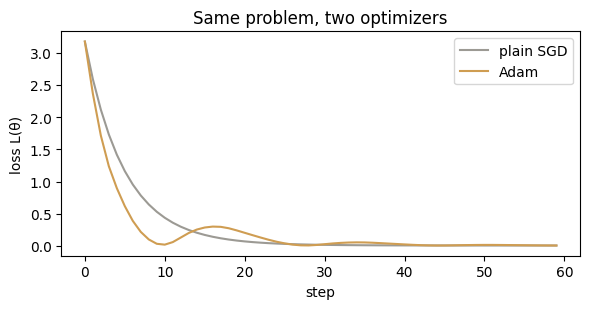

SGD  final loss: 0.00594
Adam final loss: 0.00604


In [5]:
def adam_fit(X, y, steps=60, eta=0.3, b1=0.9, b2=0.999, eps=1e-8):
    n, k = X.shape
    theta = np.zeros(k)
    m = np.zeros(k)
    v = np.zeros(k)
    losses = []
    for t in range(1, steps + 1):
        residual = X @ theta - y
        loss = 0.5 * np.mean(residual ** 2)
        g = (X.T @ residual) / n
        m = b1 * m + (1 - b1) * g
        v = b2 * v + (1 - b2) * g**2
        m_hat = m / (1 - b1**t)
        v_hat = v / (1 - b2**t)
        theta = theta - eta * m_hat / (np.sqrt(v_hat) + eps)
        losses.append(loss)
    return theta, losses

theta_adam, losses_adam = adam_fit(X, y, steps=60)

plt.figure(figsize=(6, 3.2))
plt.plot(losses, label="plain SGD", color="#9c9a94")
plt.plot(losses_adam, label="Adam", color="#cf9d52")
plt.xlabel("step"); plt.ylabel("loss L(θ)")
plt.title("Same problem, two optimizers")
plt.legend(); plt.tight_layout(); plt.show()

print("SGD  final loss: %.5f" % losses[-1])
print("Adam final loss: %.5f" % losses_adam[-1])

## 6. The key insight: low-rank structure

Every matrix $M \in \mathbb{R}^{m\times n}$ has a singular value decomposition

$$
M = U\Sigma V^\top = \sum_{i=1}^{\min(m,n)} \sigma_i\, u_i v_i^\top,
\qquad \sigma_1 \ge \sigma_2 \ge \dots \ge 0
$$

Each term $u_iv_i^\top$ is a **rank-1 matrix** (Section 7 will build one of these by hand). The
**Eckart–Young theorem** says something remarkable: if you keep only the top $r$ terms,

$$
M_r = \sum_{i=1}^{r}\sigma_i u_i v_i^\top
$$

then $M_r$ is *provably* the best possible rank-$r$ approximation of $M$ in Frobenius norm — better
than any other rank-$r$ matrix you could construct by any other method. This is the formal
backbone behind "fine-tuning updates have low intrinsic rank": if a weight-update matrix's singular
values decay quickly, a small $r$ already captures almost everything.

Let's manufacture an update matrix with quickly-decaying singular values (the way real
fine-tuning updates tend to look) and watch reconstruction error collapse as `r` grows.

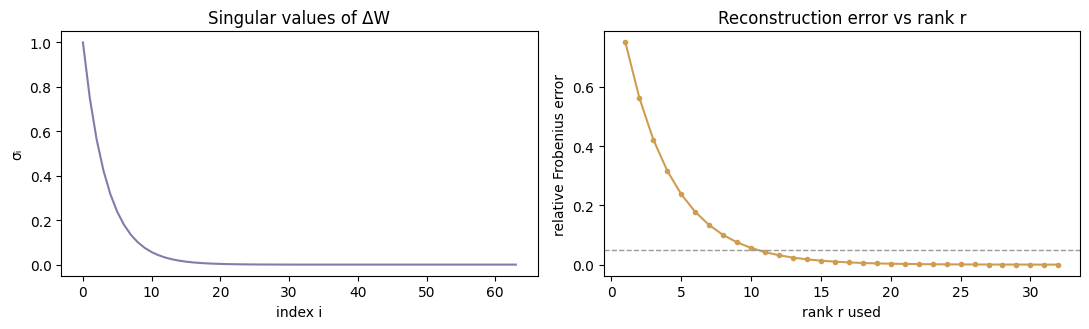

rank  1:  75.0% reconstruction error remaining
rank  2:  56.2% reconstruction error remaining
rank  4:  31.6% reconstruction error remaining
rank  8:  10.0% reconstruction error remaining
rank 16:   1.0% reconstruction error remaining


In [6]:
def make_decaying_matrix(rows, cols, decay=0.6, seed=0):
    rng_local = np.random.default_rng(seed)
    r = min(rows, cols)
    U, _ = np.linalg.qr(rng_local.normal(size=(rows, r)))
    V, _ = np.linalg.qr(rng_local.normal(size=(cols, r)))
    sigmas = decay ** np.arange(r)          # fast-decaying spectrum
    return (U * sigmas) @ V.T, sigmas

d, kdim = 64, 64
delta_W, sigmas = make_decaying_matrix(d, kdim, decay=0.75)

U, S, Vt = np.linalg.svd(delta_W, full_matrices=False)

ranks = np.arange(1, 33)
rel_errors = []
for r in ranks:
    approx = (U[:, :r] * S[:r]) @ Vt[:r, :]
    err = np.linalg.norm(delta_W - approx, "fro") / np.linalg.norm(delta_W, "fro")
    rel_errors.append(err)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].plot(S, color="#837bab")
axes[0].set_title("Singular values of ΔW"); axes[0].set_xlabel("index i"); axes[0].set_ylabel("σᵢ")

axes[1].plot(ranks, rel_errors, color="#cf9d52", marker="o", markersize=3)
axes[1].set_title("Reconstruction error vs rank r")
axes[1].set_xlabel("rank r used"); axes[1].set_ylabel("relative Frobenius error")
axes[1].axhline(0.05, ls="--", color="#9c9a94", lw=1)
plt.tight_layout(); plt.show()

for r in [1, 2, 4, 8, 16]:
    print(f"rank {r:>2d}: {rel_errors[r-1]*100:5.1f}% reconstruction error remaining")

## 7. LoRA: the math, derived and implemented

**The parameterization.** Instead of learning $\Delta W \in \mathbb{R}^{k\times d}$ directly, LoRA
writes it as a product of two much smaller matrices:

$$
\Delta W = BA, \qquad B \in \mathbb{R}^{k\times r},\ \ A \in \mathbb{R}^{r\times d}, \qquad r \ll \min(k,d)
$$

**Parameter count.** Full update: $k\times d$ numbers. LoRA update: $r(k+d)$ numbers. For
$k=d=4096,\ r=8$: $16{,}777{,}216$ vs $65{,}536$ — about **256× fewer**.

**Forward pass.** The frozen base and the LoRA path both run, and their outputs are simply added:

$$
h = xW_0 + \frac{\alpha}{r}\,x B A
$$

($\alpha/r$ is a scaling factor — Section 9 explains why it's there.)

**Backward pass — the gradients.** Let $z = xB \in \mathbb{R}^{1\times r}$ be the bottleneck
activation, and let $\delta = \partial L/\partial h \in \mathbb{R}^{1\times d}$ be the gradient
flowing back into this layer's output. By the chain rule:

$$
\frac{\partial L}{\partial A} = \frac{\alpha}{r}\, z^\top \delta,
\qquad\qquad
\frac{\partial L}{\partial B} = \frac{\alpha}{r}\, x^\top (\delta A^\top)
$$

and crucially $\partial L/\partial W_0 = 0$ — it's simply never computed, because $W_0$ is frozen.
That's the entire memory saving in one pair of equations.

Let's implement this as an actual class, with a hand-derived backward pass (no autograd), and
train only `A` and `B` to recover a hidden low-rank update.

In [7]:
class LoRALinear:
    # y = x @ W0 + (alpha/r) * x @ B @ A
    # W0 is frozen. Only B and A are trained.
    def __init__(self, W0, r, alpha=None, seed=0):
        self.W0 = W0                      # frozen, shape (k, d)
        k, d = W0.shape
        self.r = r
        self.alpha = alpha if alpha is not None else r
        self.scale = self.alpha / self.r
        rng_local = np.random.default_rng(seed)
        self.B = np.zeros((k, r))                                   # zeros  -> ΔW = 0 at init
        self.A = rng_local.normal(scale=0.01, size=(r, d))           # small random

    def forward(self, x):
        self.x = x                        # cache for backward
        self.z = x @ self.B                # bottleneck activation, shape (n, r)
        base = x @ self.W0
        lora = self.scale * (self.z @ self.A)
        return base + lora

    def backward(self, dL_dh):
        # dL_dh: gradient of the loss w.r.t. this layer's output, shape (n, d)
        n = self.x.shape[0]
        dA = self.scale * (self.z.T @ dL_dh) / n
        dz = self.scale * (dL_dh @ self.A.T)
        dB = (self.x.T @ dz) / n
        # dW0 is never computed: W0 is frozen.
        return dA, dB

    def delta_W(self):
        return self.scale * (self.B @ self.A)

    def trainable_params(self):
        return self.B.size + self.A.size

    def total_params(self):
        return self.W0.size + self.trainable_params()

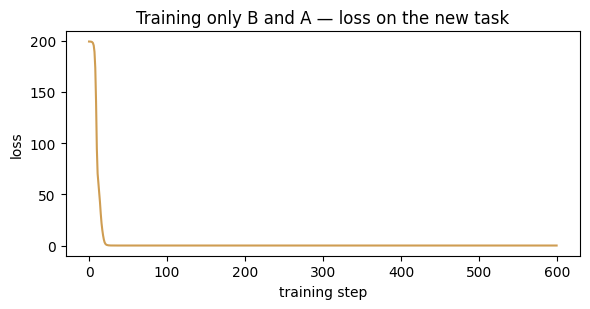

trainable params (B, A): 512
frozen params (W0):      1,024
trainable fraction:      33.33%
final loss:              0.00607
ΔW relative recon error: 0.08%


In [8]:
# ---- a toy fine-tuning task ----------------------------------------------
k, d = 32, 32
r_true = 3

W0 = rng.normal(scale=0.3, size=(k, d))                 # "pretrained" weight, frozen
B_true = rng.normal(scale=0.6, size=(k, r_true))
A_true = rng.normal(scale=0.6, size=(r_true, d))
hidden_delta = B_true @ A_true                          # the "new task" the model must learn
W_target = W0 + hidden_delta

n_samples = 300
X = rng.normal(size=(n_samples, k))
Y = X @ W_target + rng.normal(scale=0.02, size=(n_samples, d))   # noisy targets

# ---- train LoRA: only B, A are updated ------------------------------------
layer = LoRALinear(W0, r=8, alpha=16, seed=3)
eta = 0.02
lora_losses = []

for step in range(600):
    pred = layer.forward(X)
    residual = pred - Y
    loss = 0.5 * np.mean(np.sum(residual**2, axis=1))
    dL_dh = residual                       # d(0.5*||r||^2)/dr = r  (mean handled inside backward)
    dA, dB = layer.backward(dL_dh)
    layer.A -= eta * dA
    layer.B -= eta * dB
    lora_losses.append(loss)

plt.figure(figsize=(6, 3.2))
plt.plot(lora_losses, color="#cf9d52")
plt.xlabel("training step"); plt.ylabel("loss")
plt.title("Training only B and A — loss on the new task")
plt.tight_layout(); plt.show()

recovered_delta = layer.delta_W()
recon_err = np.linalg.norm(recovered_delta - hidden_delta, "fro") / np.linalg.norm(hidden_delta, "fro")

print(f"trainable params (B, A): {layer.trainable_params():,}")
print(f"frozen params (W0):      {layer.W0.size:,}")
print(f"trainable fraction:      {layer.trainable_params()/layer.total_params()*100:.2f}%")
print(f"final loss:              {lora_losses[-1]:.5f}")
print(f"ΔW relative recon error: {recon_err*100:.2f}%")

## 8. Initialization: why `B = 0`, `A = random`

Look back at the `LoRALinear.__init__` above: `B` is initialized to all zeros, `A` to small
random values. Since $\Delta W = \frac{\alpha}{r}BA$ and $B=0$:

$$
\Delta W_{\text{init}} = \frac{\alpha}{r}\cdot \mathbf{0}\cdot A = \mathbf{0}
$$

**at step zero, the adapted model is mathematically identical to the pretrained model** — no
matter what `A` happens to contain. This matters: fine-tuning starts from a model that already
works, and the adapter's influence grows in only as training actually needs it, rather than
starting with a jarring random perturbation.

In [9]:
fresh_layer = LoRALinear(W0, r=8, alpha=16, seed=42)

print("B is all zeros:", np.allclose(fresh_layer.B, 0))
print("A has nonzero values:", not np.allclose(fresh_layer.A, 0))
print("ΔW at init (max abs value):", np.abs(fresh_layer.delta_W()).max())

x_probe = rng.normal(size=(5, k))
out_adapted = fresh_layer.forward(x_probe)
out_frozen_only = x_probe @ W0
print("max |adapted_output - frozen_only_output| before training:",
      np.abs(out_adapted - out_frozen_only).max())

B is all zeros: True
A has nonzero values: True
ΔW at init (max abs value): 0.0
max |adapted_output - frozen_only_output| before training: 0.0


## 9. The scaling factor `α / r`

LoRA doesn't add $BA$ directly — it adds $\frac{\alpha}{r}BA$. The ratio $\alpha/r$ is the actual
knob: pick it once (a common default is $\alpha = 2r$, giving a ratio of 2), and it stays fixed as
a design choice no matter what rank you later decide to use. That means changing `r` — giving the
adapter more or less capacity — doesn't also silently rescale the size of every update, so a
learning rate that worked at one rank tends to keep working reasonably well at another.

This is a practical convention more than a hard theorem — later work (`rsLoRA`, mentioned in
Section 15) found that at *very* high rank, scaling by $1/\sqrt{r}$ instead of $1/r$ behaves more
stably. But the core idea — decouple "how much capacity" (`r`) from "how strong is the update"
(`α/r`) — is what matters here.

Let's confirm the practical claim: train the exact same toy task from Section 7 at very
different ranks, using the *same* learning rate throughout, and check training stays stable at
each one.

In [10]:
def train_lora_toy(r, alpha, eta=0.02, steps=600, seed=3):
    layer = LoRALinear(W0, r=r, alpha=alpha, seed=seed)
    for _ in range(steps):
        pred = layer.forward(X)
        residual = pred - Y
        dA, dB = layer.backward(residual)
        layer.A -= eta * dA
        layer.B -= eta * dB
    pred = layer.forward(X)
    return 0.5 * np.mean(np.sum((pred - Y) ** 2, axis=1))

ratio = 2   # alpha = ratio * r, held fixed as r changes
print(f"{'rank r':>8s}  {'alpha':>6s}  {'alpha/r':>8s}  {'final loss (same eta)':>22s}")
for r in [4, 8, 16, 32]:
    loss = train_lora_toy(r=r, alpha=r * ratio, eta=0.02)
    print(f"{r:>8d}  {r*ratio:>6d}  {ratio:>8.2f}  {loss:>22.5f}")

  rank r   alpha   alpha/r   final loss (same eta)


       4       8      2.00                 0.00608
       8      16      2.00                 0.00607
      16      32      2.00                 0.00604
      32      64      2.00                 0.00598


## 10. Choosing rank `r`: how much "energy" you actually need

Back to the singular values from Section 6. The squared singular values tell you how much of the
matrix's total "energy" (squared Frobenius norm) each rank-1 term contributes:

$$
\text{energy captured by rank } r = \frac{\sum_{i=1}^{r}\sigma_i^2}{\sum_{i}\sigma_i^2}
$$

This gives a principled way to pick `r`: keep adding rank until you've captured, say, 90–99% of
the energy — adding more after that mostly buys trainable parameters, not accuracy.

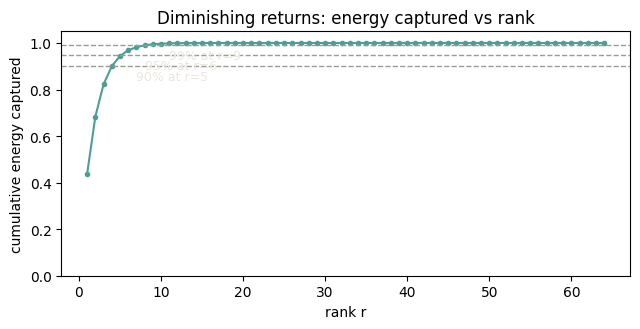

rank needed for 90% energy: r = 5
rank needed for 95% energy: r = 6
rank needed for 99% energy: r = 9


In [11]:
energy = np.cumsum(S**2) / np.sum(S**2)

plt.figure(figsize=(6.5, 3.4))
plt.plot(np.arange(1, len(S)+1), energy, color="#4f9e94", marker="o", markersize=3)
for target in [0.90, 0.95, 0.99]:
    r_needed = int(np.searchsorted(energy, target) + 1)
    plt.axhline(target, ls="--", color="#9c9a94", lw=1)
    plt.annotate(f"{int(target*100)}% at r={r_needed}", xy=(r_needed, target),
                 xytext=(r_needed+2, target-0.06), fontsize=9, color="#e9e7e0")
plt.xlabel("rank r"); plt.ylabel("cumulative energy captured")
plt.title("Diminishing returns: energy captured vs rank")
plt.ylim(0, 1.05)
plt.tight_layout(); plt.show()

for target in [0.90, 0.95, 0.99]:
    r_needed = int(np.searchsorted(energy, target) + 1)
    print(f"rank needed for {int(target*100)}% energy: r = {r_needed}")

## 11. Merging LoRA weights back into `W`

Once training is done, there's no need to keep running two separate paths at inference time.
Just fold the adapter directly into the frozen weight:

$$
W' = W_0 + \frac{\alpha}{r}BA
$$

`W'` is an ordinary matrix — same shape as `W0`, zero extra latency, zero extra parameters to
carry around at serving time. Let's verify this numerically: the merged layer must produce
*exactly* the same output as running the two paths separately.

In [12]:
W_merged = layer.W0 + layer.scale * (layer.B @ layer.A)

x_test = rng.normal(size=(10, k))
out_two_paths = layer.forward(x_test)
out_merged = x_test @ W_merged

max_diff = np.abs(out_two_paths - out_merged).max()
print("max abs difference between two-path and merged output:", max_diff)
print("(this should be ~0, up to floating point rounding)")

max abs difference between two-path and merged output: 5.329070518200751e-15
(this should be ~0, up to floating point rounding)


## 12. QLoRA: the math of NF4 quantization

LoRA already freezes $W_0$ — so why store it at full precision? **QLoRA** compresses the frozen
base into 4-bit numbers. The key design choice is *where* to place the 16 possible values.

Pretrained weights tend to be roughly normally distributed, clustered near zero. **NF4** (Normal
Float 4-bit) places its 16 levels at the **quantiles** of a standard normal distribution — dense
near the middle, sparse in the tails — instead of spacing them evenly like plain int4.

Quantizing a value $x$ (after scaling into the block's range) just means snapping it to its
nearest level:

$$
q(x) = \arg\min_{i} \; |x - \text{level}_i|
$$

Let's build both quantizers and measure which one reconstructs normally-distributed weights more
accurately.

In [13]:
from scipy.stats import norm

def make_nf4_levels():
    # 16 levels at the quantiles of a standard normal (evenly spaced probabilities)
    probs = (np.arange(16) + 0.5) / 16
    levels = norm.ppf(probs)
    return levels / np.abs(levels).max()          # normalize to roughly [-1, 1]

def make_uniform_int4_levels():
    return np.linspace(-1, 1, 16)

def quantize(values, levels, block_size=64):
    # Block-wise quantization: each block gets its own scale (absmax).
    out = np.empty_like(values)
    n = len(values)
    for start in range(0, n, block_size):
        block = values[start:start+block_size]
        scale = np.abs(block).max() + 1e-8
        normalized = block / scale
        idx = np.argmin(np.abs(normalized[:, None] - levels[None, :]), axis=1)
        out[start:start+block_size] = levels[idx] * scale
    return out

nf4_levels = make_nf4_levels()
uniform_levels = make_uniform_int4_levels()

weights = rng.normal(size=20_000)                  # stand-in for a real weight tensor

nf4_reconstructed = quantize(weights, nf4_levels)
uniform_reconstructed = quantize(weights, uniform_levels)

mse_nf4 = np.mean((weights - nf4_reconstructed) ** 2)
mse_uniform = np.mean((weights - uniform_reconstructed) ** 2)

print(f"NF4      reconstruction MSE: {mse_nf4:.6f}")
print(f"uniform  reconstruction MSE: {mse_uniform:.6f}")
print(f"NF4 is {mse_uniform/mse_nf4:.2f}x more accurate on normally-distributed weights")

NF4      reconstruction MSE: 0.008343
uniform  reconstruction MSE: 0.010160
NF4 is 1.22x more accurate on normally-distributed weights


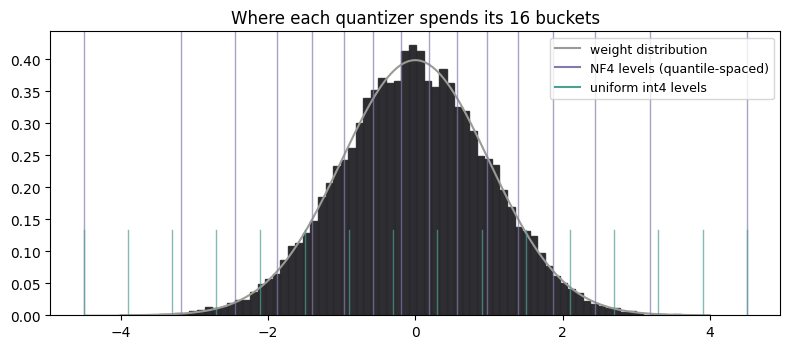

In [14]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.hist(weights, bins=80, density=True, color="#17171b", edgecolor="#29292e", alpha=0.9)
xs = np.linspace(-4, 4, 400)
ax.plot(xs, norm.pdf(xs), color="#9c9a94", lw=1.5, label="weight distribution")

for lv in nf4_levels * np.abs(weights).max():
    ax.axvline(lv, color="#837bab", lw=1, alpha=0.7)
for lv in uniform_levels * np.abs(weights).max():
    ax.axvline(lv, color="#4f9e94", lw=1, ymax=0.3, alpha=0.7)

ax.plot([], [], color="#837bab", label="NF4 levels (quantile-spaced)")
ax.plot([], [], color="#4f9e94", label="uniform int4 levels")
ax.set_title("Where each quantizer spends its 16 buckets")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 13. Double quantization: compressing the compression

Notice the `quantize` function above stores one `scale` (a 32-bit float) *per block*. For a
block size of 64, that's:

$$
\text{overhead per weight} = \frac{32 \text{ bits}}{64 \text{ weights}} = 0.5 \text{ bits/weight}
$$

Small, but not free — and at billions of parameters it adds up. **Double quantization** quantizes
those scale constants too: instead of storing each one as fp32, store them as 8-bit numbers, with
one shared 32-bit "meta-scale" for every 256 of them:

$$
\text{overhead per weight} = \frac{8}{64} + \frac{32}{64 \times 256}
= 0.125 + 0.00195 \approx 0.127 \text{ bits/weight}
$$

In [15]:
def quant_overhead_bits_per_weight(const_bits, block_size, meta_bits=0, super_block=1):
    per_weight = const_bits / block_size
    if super_block > 1:
        per_weight += meta_bits / (block_size * super_block)
    return per_weight

single_q = quant_overhead_bits_per_weight(const_bits=32, block_size=64)
double_q = quant_overhead_bits_per_weight(const_bits=8, block_size=64, meta_bits=32, super_block=256)

print(f"single quantization overhead: {single_q:.4f} bits/weight")
print(f"double quantization overhead: {double_q:.4f} bits/weight")
print(f"savings: {single_q - double_q:.4f} bits/weight "
      f"({(1 - double_q/single_q)*100:.1f}% reduction in overhead)")

model_params = 65_000_000_000  # a 65B-parameter model, for scale
saved_bits = (single_q - double_q) * model_params
saved_gb = saved_bits / 8 / 1e9
print(f"\nOn a {model_params/1e9:.0f}B-parameter model, that's about {saved_gb:.2f} GB saved"
      f" — just from compressing the scale constants.")

single quantization overhead: 0.5000 bits/weight
double quantization overhead: 0.1270 bits/weight
savings: 0.3730 bits/weight (74.6% reduction in overhead)

On a 65B-parameter model, that's about 3.03 GB saved — just from compressing the scale constants.


## 14. Full memory comparison: Full FT vs LoRA vs QLoRA

Now let's put every formula from this notebook together into one comparison, for a realistic
~7B-parameter model. We'll assume LoRA/QLoRA target all six matrices in every block
(Section 4's `12d²` breakdown) at rank `r=16`.

In [16]:
d_model, n_layers, r = 4096, 32, 16
total_params = transformer_param_estimate(d_model, n_layers)

# LoRA trainable params: r*(k+d) per adapted matrix, 6 matrices/block (4 attn + 2 mlp-ish, using d for both dims here)
matrices_per_block = 6
lora_trainable = matrices_per_block * n_layers * r * (d_model + d_model)
trainable_fraction = lora_trainable / total_params

def scenario_row(name, base_weight_bytes, trainable_fraction, grad_bytes=2, opt_bytes=4, opt_states=2):
    bill = memory_bill_gb(total_params, trainable_fraction=trainable_fraction,
                           weight_bytes=base_weight_bytes, grad_bytes=grad_bytes,
                           opt_bytes=opt_bytes, opt_states=opt_states)
    return {
        "method": name,
        "trainable_params": int(total_params * trainable_fraction),
        "trainable_%": round(trainable_fraction * 100, 3),
        "weights_GB": round(bill["weights_GB"], 2),
        "grads+optimizer_GB": round(bill["grads_GB"] + bill["optimizer_GB"], 2),
        "total_GB": round(bill["total_GB"], 2),
    }

rows = [
    scenario_row("Full fine-tuning", base_weight_bytes=2, trainable_fraction=1.0),
    scenario_row("LoRA (fp16 base)", base_weight_bytes=2, trainable_fraction=trainable_fraction),
    scenario_row("QLoRA (4-bit base)", base_weight_bytes=0.5, trainable_fraction=trainable_fraction),
]

comparison = pd.DataFrame(rows)
comparison

,method,trainable_params,trainable_%,weights_GB,grads+optimizer_GB,total_GB
0,Full fine-tuning,6442450944,100.000,12.88,64.42,77.31
1,LoRA (fp16 base),25165824,0.391,12.88,0.25,13.14
2,QLoRA (4-bit base),25165824,0.391,3.22,0.25,3.47


## 15. Real-world usage with 🤗 `peft` (reference only)

Everything above was implemented from scratch to make the math visible. In practice, you'd use
the Hugging Face `peft` library, which wraps real `torch.nn.Linear` layers the same way our
`LoRALinear` class did. This cell is **illustrative only** (not executed here — it needs
`transformers`, `peft`, and a downloaded model):

```python
# pip install transformers peft accelerate bitsandbytes

from transformers import AutoModelForCausalLM, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model

# --- QLoRA: load the frozen base model in 4-bit (NF4) ---
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype="bfloat16",
)
base_model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-2-7b-hf", quantization_config=bnb_config
)

# --- LoRA: attach trainable adapters ---
lora_config = LoraConfig(
    r=16, lora_alpha=32, lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],  # Section 4/7's Wq,Wk,Wv,Wo
    task_type="CAUSAL_LM",
)
model = get_peft_model(base_model, lora_config)
model.print_trainable_parameters()
# -> "trainable params: 8,388,608 || all params: 6,746,804,224 || trainable%: 0.124"
```

Notice how directly that final line echoes Sections 4, 7, and 14 of this notebook — the same
`r(k+d)` arithmetic, just running on a real 7B model instead of a 32×32 toy.

## 16. Cheat sheet

| Concept | Formula | Meaning |
|---|---|---|
| gradient step | $\theta \leftarrow \theta - \eta\, \partial L/\partial\theta$ | move against the gradient |
| Adam update | $\theta \leftarrow \theta - \eta\, \hat m/(\sqrt{\hat v}+\epsilon)$ | smoothed direction & step size |
| transformer size | $\text{params} \approx 12d^2L$ | attention (4d²) + MLP (8d²), per layer |
| SVD | $M=\sum_i \sigma_i u_i v_i^\top$ | any matrix as a sum of rank-1 pieces |
| Eckart–Young | $M_r=\sum_{i\le r}\sigma_i u_i v_i^\top$ | provably-best rank-$r$ approximation |
| LoRA parameterization | $\Delta W = BA$ | $B\in\mathbb{R}^{k\times r}$, $A\in\mathbb{R}^{r\times d}$ |
| LoRA forward | $h = xW_0 + \frac{\alpha}{r}xBA$ | frozen path + scaled bypass, summed |
| LoRA param count | $r(k+d)$ vs $kd$ | the actual saving |
| LoRA init | $B=0,\ A\sim\mathcal N(0,\sigma^2)$ | $\Delta W=0$ at step zero |
| merge for inference | $W' = W_0+\frac{\alpha}{r}BA$ | one matrix, zero extra latency |
| NF4 quantization | levels at $\Phi^{-1}\!\left(\frac{i+0.5}{16}\right)$ | resolution where the weights actually are |
| double quantization | quantize the per-block scale constants too | ~0.5 → ~0.13 bits/weight overhead |

**One-sentence recap of the whole story:** freeze what already works, and train the smallest
low-rank patch that can still learn the new trick — then, if memory is still tight, compress the
frozen giant itself down to 4 bits.

*Companion resource: the animated HTML slide deck covers the same material with visual, motion-based
intuition — this notebook is where the math and code live.*